<a href="https://colab.research.google.com/github/harshsu7/Linear-Regression/blob/main/Kmeans_%26_Hierarchal_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head(-10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
185,186,Male,30,99,97
186,187,Female,54,101,24
187,188,Male,28,101,68
188,189,Female,41,103,17


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.replace("Male",1,inplace=True)
df.replace("Female",0,inplace=True)
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
104,105,1,49,62,56
140,141,0,57,75,5
138,139,1,19,74,10
132,133,0,25,72,34
159,160,0,30,78,73


In [11]:
x = df[["Annual Income (k$)","Spending Score (1-100)"]]

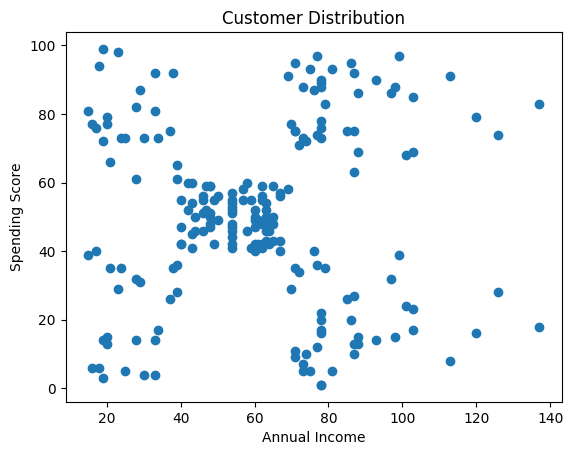

In [13]:
plt.scatter(x.iloc[:,0], x.iloc[:,1])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

- Everything seems to be **random** right now - Aim of Kmeans is to find pattern among these random values and give us these points in clusters

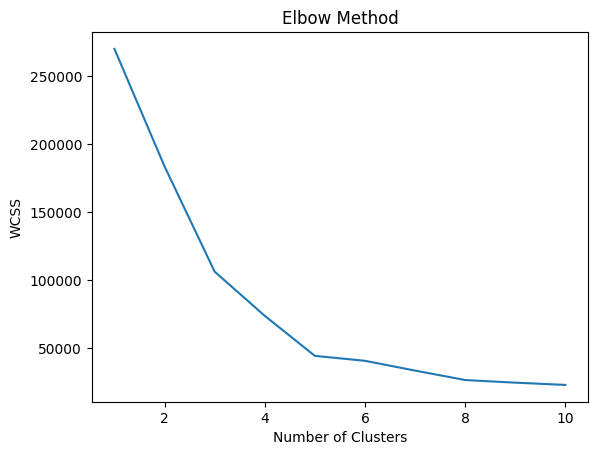

In [15]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

- Elbow methods helps us to find best K for our Model - Wherever the Graph bends that is our K
- In above graph - best k is at 5

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(x)

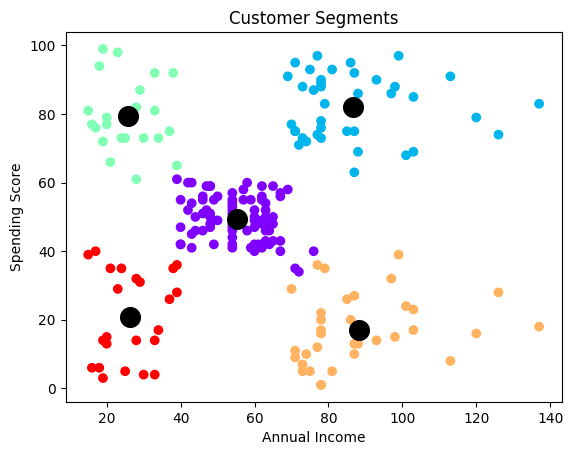

In [20]:
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_kmeans, cmap='rainbow')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='black', s=200)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

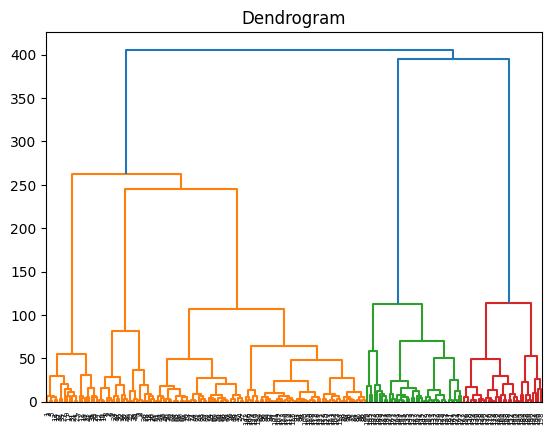

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(x, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)

y_hc = hc.fit_predict(x)

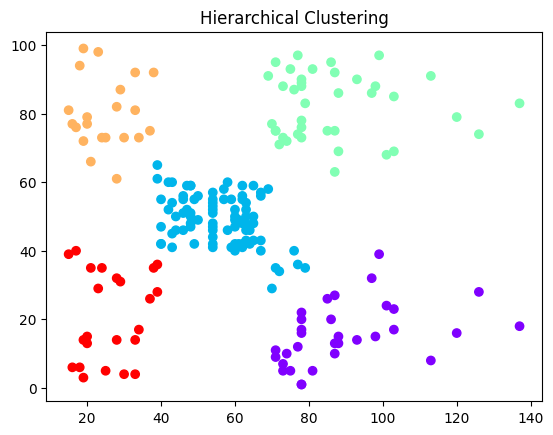

In [27]:
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_hc, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.show()

In [28]:
X_3d = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

In [29]:
from sklearn.cluster import KMeans

kmeans_3d = KMeans(n_clusters=5, random_state=42)

y_kmeans_3d = kmeans_3d.fit_predict(X_3d)

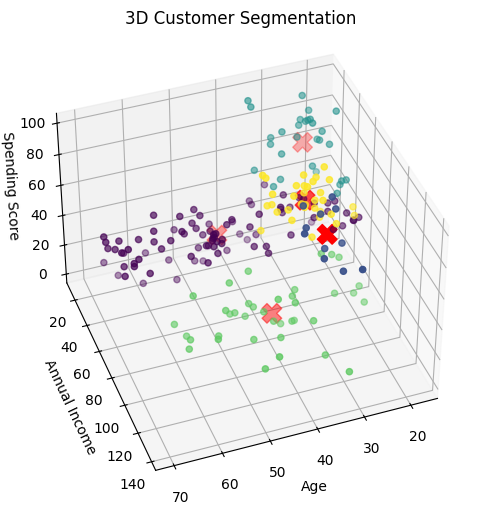

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=40, azim=70)

ax.scatter(
    X_3d.iloc[:,0],  # Age
    X_3d.iloc[:,1],  # Income
    X_3d.iloc[:,2],  # Spending
    c=y_kmeans_3d
)
centroids = kmeans_3d.cluster_centers_

ax.scatter(
    centroids[:,0],
    centroids[:,1],
    centroids[:,2],
    s=200,
    c='red',
    marker='X'
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")

plt.title("3D Customer Segmentation")
plt.show()